Generating input points...

=== Uniform Random Input ===

Algorithm Comparison:
Algorithm                      Rectangles Used      Coverage        Execution Time (s)   Overlap Ratio   Efficiency     
--------------------------------------------------------------------------------------------------------------
Greedy Incremental Cover       45                   0.8600            0.001504               0.3375            2.2222
Cluster-Growing Adaptive       42                   0.8600            0.017053               0.3155            2.3810
Lazy Greedy with Lookahead     45                   0.8600            0.010039               0.3375            2.2222

=== Clustered Input ===

Algorithm Comparison:
Algorithm                      Rectangles Used      Coverage        Execution Time (s)   Overlap Ratio   Efficiency     
--------------------------------------------------------------------------------------------------------------
Greedy Incremental Cover       26                   0.

MovieWriter ffmpeg unavailable; using Pillow instead.



Creating animations (with fallback options)...
Attempting to save Greedy Incremental Cover animation as .mp4...
Failed to save as .mp4: unknown file extension: .mp4
Attempting to save Greedy Incremental Cover animation as .gif...


MovieWriter ffmpeg unavailable; using Pillow instead.


Successfully saved animation to results/animations/greedy_animation.gif
Attempting to save Cluster-Growing Adaptive Cover animation as .mp4...
Failed to save as .mp4: unknown file extension: .mp4
Attempting to save Cluster-Growing Adaptive Cover animation as .gif...


MovieWriter ffmpeg unavailable; using Pillow instead.
MovieWriter html5 unavailable; using Pillow instead.


Successfully saved animation to results/animations/cluster_animation.gif
Attempting to save Lazy Greedy with Lookahead animation as .mp4...
Failed to save as .mp4: list index out of range
Attempting to save Lazy Greedy with Lookahead animation as .gif...
Failed to save as .gif: list index out of range
Attempting to save Lazy Greedy with Lookahead animation as .html...
Failed to save as .html: list index out of range
Could not save animation in any format. Saving static frames instead...
Saving static frames for Lazy Greedy with Lookahead...

Experiment completed!


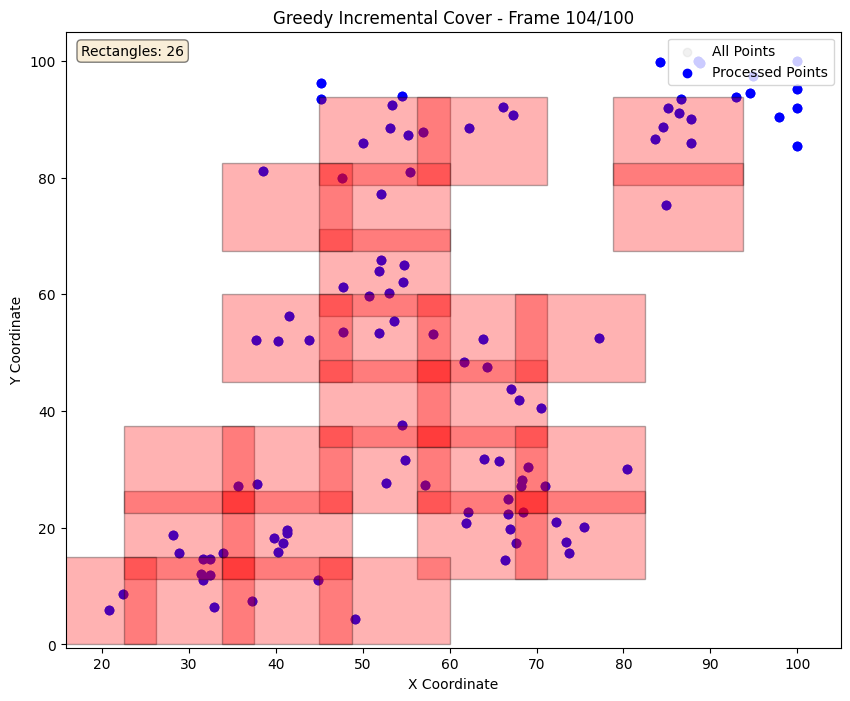

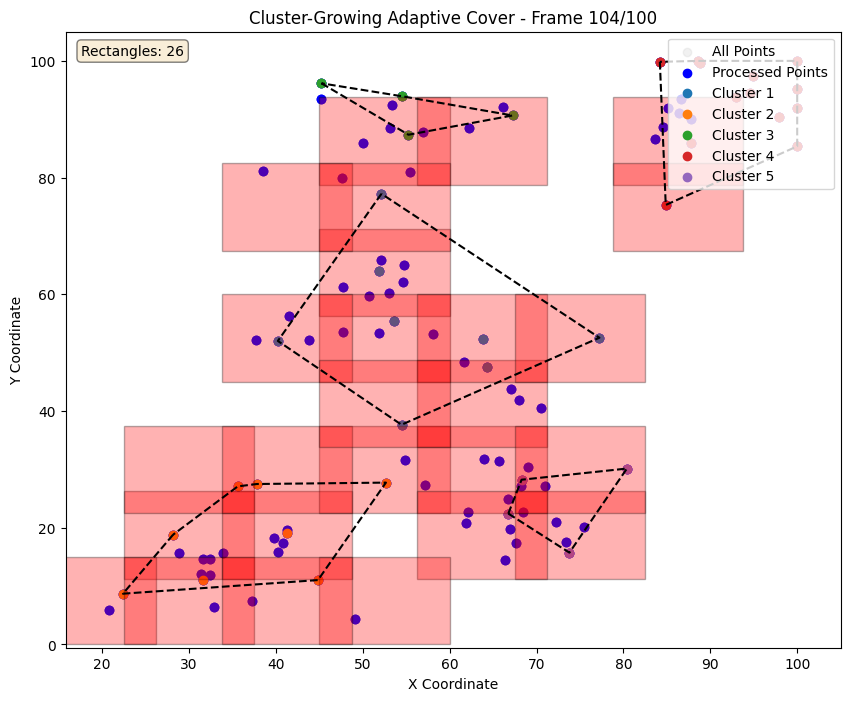

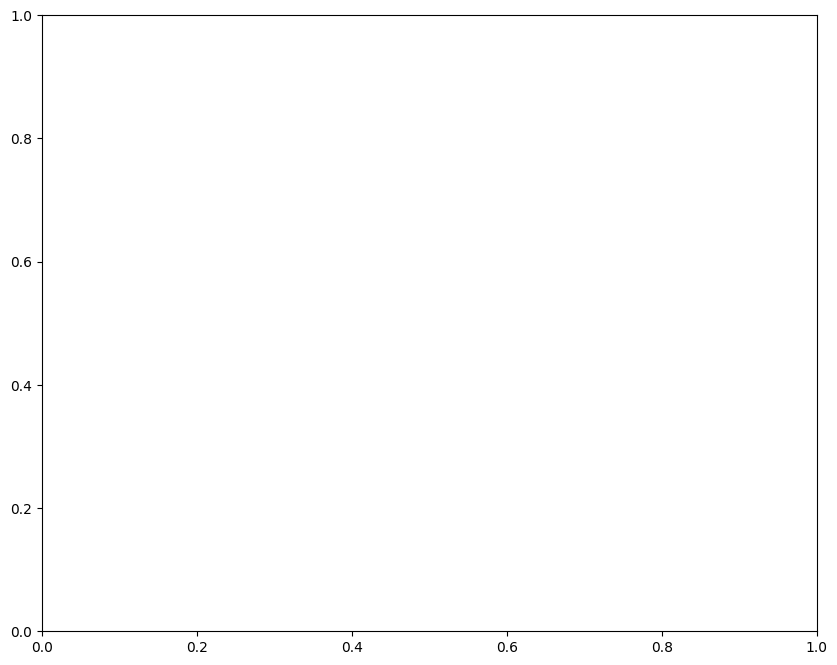

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.spatial import ConvexHull
import random
from typing import List, Tuple
import time
from matplotlib.animation import FuncAnimation
import os

# Define basic data structures
class Point:
    def __init__(self, x: float, y: float):
        self.x = x
        self.y = y
    
    def as_tuple(self) -> Tuple[float, float]:
        return (self.x, self.y)
    
    def distance_to(self, other: 'Point') -> float:
        return np.sqrt((self.x - other.x) ** 2 + (self.y - other.y) ** 2)

class Rect:
    def __init__(self, x: float, y: float, width: float, height: float):
        self.x = x
        self.y = y
        self.width = width
        self.height = height
    
    def contains(self, point: Point) -> bool:
        return (self.x <= point.x <= self.x + self.width and
                self.y <= point.y <= self.y + self.height)
    
    def as_patch(self, **kwargs):
        return Rectangle((self.x, self.y), self.width, self.height, **kwargs)
    
    def area(self) -> float:
        return self.width * self.height
    
    def overlap_area(self, other: 'Rect') -> float:
        x_overlap = max(0, min(self.x + self.width, other.x + other.width) - max(self.x, other.x))
        y_overlap = max(0, min(self.y + self.height, other.y + other.height) - max(self.y, other.y))
        return x_overlap * y_overlap

class Cluster:
    def __init__(self, initial_point: Point):
        self.points = [initial_point]
        self.update_hull()
    
    def add_point(self, point: Point):
        self.points.append(point)
        self.update_hull()
    
    def update_hull(self):
        if len(self.points) <= 2:
            self.hull_points = self.points
        else:
            points_array = np.array([p.as_tuple() for p in self.points])
            hull = ConvexHull(points_array)
            self.hull_points = [self.points[i] for i in hull.vertices]
    
    def distance_to_point(self, point: Point) -> float:
        return min(point.distance_to(p) for p in self.points)
    
    def is_within_threshold(self, point: Point, threshold: float) -> bool:
        return self.distance_to_point(point) <= threshold

# Functions to generate input sequences
def generate_uniform_random_points(n: int, bounds: Tuple[float, float, float, float]) -> List[Point]:
    x_min, x_max, y_min, y_max = bounds
    return [Point(random.uniform(x_min, x_max), random.uniform(y_min, y_max)) for _ in range(n)]

def generate_clustered_points(n: int, num_clusters: int, cluster_std: float, bounds: Tuple[float, float, float, float]) -> List[Point]:
    x_min, x_max, y_min, y_max = bounds
    points = []
    
    # Generate cluster centers
    cluster_centers = [Point(random.uniform(x_min + cluster_std, x_max - cluster_std), 
                             random.uniform(y_min + cluster_std, y_max - cluster_std)) 
                       for _ in range(num_clusters)]
    
    # Assign points to clusters
    for _ in range(n):
        center = random.choice(cluster_centers)
        x = random.gauss(center.x, cluster_std)
        y = random.gauss(center.y, cluster_std)
        # Ensure points stay within bounds
        x = max(x_min, min(x_max, x))
        y = max(y_min, min(y_max, y))
        points.append(Point(x, y))
    
    return points

def generate_adversarial_points(n: int, rect_width: float, rect_height: float, bounds: Tuple[float, float, float, float]) -> List[Point]:
    x_min, x_max, y_min, y_max = bounds
    points = []
    
    # Strategy: Create a sequence where each new point is just outside the coverage of previous rectangles
    step_x = rect_width * 1.01  # Slightly larger than rectangle width
    step_y = rect_height * 1.01  # Slightly larger than rectangle height
    
    x, y = x_min, y_min
    for _ in range(n):
        points.append(Point(x, y))
        
        # Move to next position
        x += step_x
        if x > x_max - rect_width:
            x = x_min
            y += step_y
            if y > y_max - rect_height:
                y = y_min
                x_min += rect_width / 2
                x = x_min
    
    return points

# Generate available rectangles
def generate_available_rectangles(bounds: Tuple[float, float, float, float], rect_width: float, rect_height: float, overlap: float = 0.5) -> List[Rect]:
    x_min, x_max, y_min, y_max = bounds
    rects = []
    
    # Calculate step size based on desired overlap
    step_x = rect_width * (1 - overlap)
    step_y = rect_height * (1 - overlap)
    
    # Generate rectangles
    x = x_min
    while x < x_max - rect_width:
        y = y_min
        while y < y_max - rect_height:
            rects.append(Rect(x, y, rect_width, rect_height))
            y += step_y
        x += step_x
    
    return rects

# Algorithm 1: Greedy Incremental Cover
def greedy_incremental_cover(points: List[Point], available_rects: List[Rect]) -> List[Rect]:
    selected_rects = []
    
    for point in points:
        # Check if the point is covered by any existing rectangle
        covered = False
        for rect in selected_rects:
            if rect.contains(point):
                covered = True
                break
        
        if not covered:
            # Find a rectangle that covers the point
            for rect in available_rects:
                if rect.contains(point):
                    selected_rects.append(rect)
                    break
    
    return selected_rects

# Algorithm 2: Cluster-Growing Adaptive Cover
def cluster_growing_adaptive_cover(points: List[Point], available_rects: List[Rect], threshold: float) -> List[Rect]:
    clusters = []
    selected_rects = []
    
    for point in points:
        # Check if the point is already covered
        covered = False
        for rect in selected_rects:
            if rect.contains(point):
                covered = True
                break
        
        if covered:
            continue
        
        # Check if the point belongs to any existing cluster
        assigned_to_cluster = False
        for cluster in clusters:
            if cluster.is_within_threshold(point, threshold):
                cluster.add_point(point)
                assigned_to_cluster = True
                break
        
        if not assigned_to_cluster:
            # Create a new cluster
            clusters.append(Cluster(point))
        
        # Find a rectangle to cover the point
        best_rect = None
        max_future_coverage = 0
        
        for rect in available_rects:
            if rect.contains(point):
                # Estimate how well this rectangle might cover future points
                # by checking how many existing cluster points it covers
                coverage = 0
                for cluster in clusters:
                    coverage += sum(1 for p in cluster.points if rect.contains(p))
                
                if coverage > max_future_coverage:
                    max_future_coverage = coverage
                    best_rect = rect
        
        if best_rect:
            selected_rects.append(best_rect)
    
    return selected_rects

# Algorithm 3: Lazy Greedy with Lookahead
def lazy_greedy_with_lookahead(points: List[Point], available_rects: List[Rect], lookahead: int) -> List[Rect]:
    selected_rects = []
    uncovered_points = []
    
    for i, point in enumerate(points):
        # Check if the point is covered by any existing rectangle
        covered = False
        for rect in selected_rects:
            if rect.contains(point):
                covered = True
                break
        
        if not covered:
            uncovered_points.append(point)
        
        # If we have enough uncovered points or this is the last point, add a rectangle
        if len(uncovered_points) >= lookahead or i == len(points) - 1:
            if uncovered_points:
                # Find the rectangle that covers the most uncovered points
                best_rect = None
                max_covered = 0
                
                for rect in available_rects:
                    covered_count = sum(1 for p in uncovered_points if rect.contains(p))
                    if covered_count > max_covered:
                        max_covered = covered_count
                        best_rect = rect
                
                if best_rect:
                    selected_rects.append(best_rect)
                    # Update the list of uncovered points
                    uncovered_points = [p for p in uncovered_points if not best_rect.contains(p)]
    
    return selected_rects

# Visualization and animation functions
def visualize_results(points: List[Point], rects: List[Rect], title: str, save_path: str = None):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot points
    x_coords = [p.x for p in points]
    y_coords = [p.y for p in points]
    ax.scatter(x_coords, y_coords, color='blue', label='Points')
    
    # Plot rectangles
    for rect in rects:
        ax.add_patch(rect.as_patch(alpha=0.3, facecolor='red', edgecolor='black'))
    
    ax.set_xlim(min(x_coords) - 5, max(x_coords) + 5)
    ax.set_ylim(min(y_coords) - 5, max(y_coords) + 5)
    ax.set_title(title)
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.text(0.02, 0.98, f'Rectangles: {len(rects)}', transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.legend()
    
    if save_path:
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()

def animate_algorithm(points: List[Point], available_rects: List[Rect], algorithm_name: str, **kwargs):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Extract bounds from points
    x_coords = [p.x for p in points]
    y_coords = [p.y for p in points]
    x_min, x_max = min(x_coords) - 5, max(x_coords) + 5
    y_min, y_max = min(y_coords) - 5, max(y_coords) + 5
    
    # Initialize algorithm state
    processed_points = []
    selected_rects = []
    clusters = []
    uncovered_points = []
    lookahead = kwargs.get('lookahead', 3)
    threshold = kwargs.get('threshold', 10.0)
    
    def init():
        ax.clear()
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        return []
    
    def update(frame):
        ax.clear()
        
        # Add the next point
        if frame < len(points):
            point = points[frame]
            processed_points.append(point)
            
            # Update algorithm state based on the new point
            if algorithm_name == "Greedy Incremental Cover":
                # Check if the point is covered by existing rectangles
                covered = False
                for rect in selected_rects:
                    if rect.contains(point):
                        covered = True
                        break
                
                if not covered:
                    # Find a rectangle that covers the point
                    for rect in available_rects:
                        if rect.contains(point):
                            selected_rects.append(rect)
                            break
            
            elif algorithm_name == "Cluster-Growing Adaptive Cover":
                # Check if the point is covered by existing rectangles
                covered = False
                for rect in selected_rects:
                    if rect.contains(point):
                        covered = True
                        break
                
                if not covered:
                    # Check if the point belongs to any existing cluster
                    assigned_to_cluster = False
                    for cluster in clusters:
                        if cluster.is_within_threshold(point, threshold):
                            cluster.add_point(point)
                            assigned_to_cluster = True
                            break
                    
                    if not assigned_to_cluster:
                        # Create a new cluster
                        clusters.append(Cluster(point))
                    
                    # Find a rectangle to cover the point
                    best_rect = None
                    max_future_coverage = 0
                    
                    for rect in available_rects:
                        if rect.contains(point):
                            # Estimate how well this rectangle might cover future points
                            coverage = 0
                            for cluster in clusters:
                                coverage += sum(1 for p in cluster.points if rect.contains(p))
                            
                            if coverage > max_future_coverage:
                                max_future_coverage = coverage
                                best_rect = rect
                    
                    if best_rect:
                        selected_rects.append(best_rect)
            
            elif algorithm_name == "Lazy Greedy with Lookahead":
                # Check if the point is covered by existing rectangles
                covered = False
                for rect in selected_rects:
                    if rect.contains(point):
                        covered = True
                        break
                
                if not covered:
                    uncovered_points.append(point)
                
                # If we have enough uncovered points or this is the last point, add a rectangle
                if len(uncovered_points) >= lookahead or frame == len(points) - 1:
                    if uncovered_points:
                        # Find the rectangle that covers the most uncovered points
                        best_rect = None
                        max_covered = 0
                        
                        for rect in available_rects:
                            covered_count = sum(1 for p in uncovered_points if rect.contains(p))
                            if covered_count > max_covered:
                                max_covered = covered_count
                                best_rect = rect
                        
                        if best_rect:
                            selected_rects.append(best_rect)
                            # Update the list of uncovered points
                            uncovered_points = [p for p in uncovered_points if not best_rect.contains(p)]
        
        # Plot all points in gray
        ax.scatter(x_coords, y_coords, color='lightgray', alpha=0.3, label='All Points')
        
        # Plot processed points in blue
        if processed_points:
            ax.scatter([p.x for p in processed_points], [p.y for p in processed_points], color='blue', label='Processed Points')
        
        # Plot algorithm-specific visualizations
        if algorithm_name == "Cluster-Growing Adaptive Cover" and clusters:
            # Plot clusters and their convex hulls
            for i, cluster in enumerate(clusters):
                if len(cluster.points) > 1:  # Only plot clusters with more than one point
                    cluster_x = [p.x for p in cluster.points]
                    cluster_y = [p.y for p in cluster.points]
                    ax.scatter(cluster_x, cluster_y, label=f'Cluster {i+1}' if i < 5 else "")
                    
                    # Plot convex hull
                    if len(cluster.hull_points) > 2:
                        hull_x = [p.x for p in cluster.hull_points] + [cluster.hull_points[0].x]
                        hull_y = [p.y for p in cluster.hull_points] + [cluster.hull_points[0].y]
                        ax.plot(hull_x, hull_y, 'k--')
        
        elif algorithm_name == "Lazy Greedy with Lookahead" and uncovered_points:
            # Plot uncovered points in red
            ax.scatter([p.x for p in uncovered_points], [p.y for p in uncovered_points], color='red', label='Uncovered Points')
        
        # Plot rectangles
        for rect in selected_rects:
            ax.add_patch(rect.as_patch(alpha=0.3, facecolor='red', edgecolor='black'))
        
        # Set layout
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_title(f'{algorithm_name} - Frame {frame}/{len(points)}')
        ax.set_xlabel('X Coordinate')
        ax.set_ylabel('Y Coordinate')
        ax.text(0.02, 0.98, f'Rectangles: {len(selected_rects)}', transform=ax.transAxes, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax.legend(loc='upper right')
        
        return []
    
    anim = FuncAnimation(fig, update, frames=len(points) + 5, init_func=init, interval=200, blit=False)
    return anim

# Evaluation function
def evaluate_algorithms(points: List[Point], available_rects: List[Rect], lookahead: int = 3, threshold: float = 10.0):
    # Evaluate Greedy Incremental Cover
    start_time = time.time()
    greedy_rects = greedy_incremental_cover(points, available_rects)
    greedy_time = time.time() - start_time
    
    # Evaluate Cluster-Growing Adaptive Cover
    start_time = time.time()
    cluster_rects = cluster_growing_adaptive_cover(points, available_rects, threshold)
    cluster_time = time.time() - start_time
    
    # Evaluate Lazy Greedy with Lookahead
    start_time = time.time()
    lazy_rects = lazy_greedy_with_lookahead(points, available_rects, lookahead)
    lazy_time = time.time() - start_time
    
    # Calculate metrics
    def calculate_coverage(rects):
        covered_points = 0
        for point in points:
            for rect in rects:
                if rect.contains(point):
                    covered_points += 1
                    break
        return covered_points / len(points)
    
    def calculate_overlap_ratio(rects):
        if not rects:
            return 0
            
        total_area = sum(rect.area() for rect in rects)
        overlap_area = 0
        for i in range(len(rects)):
            for j in range(i + 1, len(rects)):
                overlap_area += rects[i].overlap_area(rects[j])
        
        return overlap_area / total_area if total_area > 0 else 0
    
    def calculate_efficiency(rects):
        # Efficiency = (Number of points covered) / (Number of rectangles used)
        return len(points) / len(rects) if rects else 0
    
    greedy_coverage = calculate_coverage(greedy_rects)
    cluster_coverage = calculate_coverage(cluster_rects)
    lazy_coverage = calculate_coverage(lazy_rects)
    
    greedy_overlap = calculate_overlap_ratio(greedy_rects)
    cluster_overlap = calculate_overlap_ratio(cluster_rects)
    lazy_overlap = calculate_overlap_ratio(lazy_rects)
    
    greedy_efficiency = calculate_efficiency(greedy_rects)
    cluster_efficiency = calculate_efficiency(cluster_rects)
    lazy_efficiency = calculate_efficiency(lazy_rects)
    
    # Print results
    print("\nAlgorithm Comparison:")
    print(f"{'Algorithm':<30} {'Rectangles Used':<20} {'Coverage':<15} {'Execution Time (s)':<20} {'Overlap Ratio':<15} {'Efficiency':<15}")
    print("-" * 110)
    print(f"{'Greedy Incremental Cover':<30} {len(greedy_rects):<20} {greedy_coverage:.4f}{'':>11} {greedy_time:.6f}{'':>14} {greedy_overlap:.4f}{'':>11} {greedy_efficiency:.4f}")
    print(f"{'Cluster-Growing Adaptive':<30} {len(cluster_rects):<20} {cluster_coverage:.4f}{'':>11} {cluster_time:.6f}{'':>14} {cluster_overlap:.4f}{'':>11} {cluster_efficiency:.4f}")
    print(f"{'Lazy Greedy with Lookahead':<30} {len(lazy_rects):<20} {lazy_coverage:.4f}{'':>11} {lazy_time:.6f}{'':>14} {lazy_overlap:.4f}{'':>11} {lazy_efficiency:.4f}")
    
    return {
        'greedy': {'rects': greedy_rects, 'coverage': greedy_coverage, 'time': greedy_time, 'overlap': greedy_overlap, 'efficiency': greedy_efficiency},
        'cluster': {'rects': cluster_rects, 'coverage': cluster_coverage, 'time': cluster_time, 'overlap': cluster_overlap, 'efficiency': cluster_efficiency},
        'lazy': {'rects': lazy_rects, 'coverage': lazy_coverage, 'time': lazy_time, 'overlap': lazy_overlap, 'efficiency': lazy_efficiency}
    }

def save_animation(anim, base_filename, algorithm_name):
    """Attempts to save animation in multiple formats with fallbacks."""
    formats_to_try = [
        (".mp4", "ffmpeg"),
        (".gif", "pillow"),
        (".html", "html5")
    ]
    
    for ext, writer in formats_to_try:
        try:
            filename = f"{base_filename}{ext}"
            print(f"Attempting to save {algorithm_name} animation as {ext}...")
            anim.save(filename, writer=writer)
            print(f"Successfully saved animation to {filename}")
            return True
        except Exception as e:
            print(f"Failed to save as {ext}: {e}")
    
    print("Could not save animation in any format. Saving static frames instead...")
    return False

# Main function
def main():
    # Create output directories
    os.makedirs('results', exist_ok=True)
    os.makedirs('results/images', exist_ok=True)
    os.makedirs('results/animations', exist_ok=True)
    os.makedirs('results/frames', exist_ok=True)  # For static frames
    
    # Set parameters
    num_points = 100
    bounds = (0, 100, 0, 100)
    rect_width = 15
    rect_height = 15
    lookahead = 5
    threshold = 15.0
    
    # Generate available rectangles with some overlap
    available_rects = generate_available_rectangles(bounds, rect_width, rect_height, overlap=0.25)
    
    # Generate points for each input setting
    print("Generating input points...")
    uniform_points = generate_uniform_random_points(num_points, bounds)
    clustered_points = generate_clustered_points(num_points, 5, 7.0, bounds)
    adversarial_points = generate_adversarial_points(num_points, rect_width, rect_height, bounds)
    
    # Evaluate algorithms on each input setting
    print("\n=== Uniform Random Input ===")
    uniform_results = evaluate_algorithms(uniform_points, available_rects, lookahead, threshold)
    
    print("\n=== Clustered Input ===")
    clustered_results = evaluate_algorithms(clustered_points, available_rects, lookahead, threshold)
    
    print("\n=== Adversarial Input ===")
    adversarial_results = evaluate_algorithms(adversarial_points, available_rects, lookahead, threshold)
    
    # Generate static visualizations
    print("\nGenerating static visualizations...")
    
    # Create static visualizations for all algorithm/data combinations
    for data_type, points, results in [
        ("uniform", uniform_points, uniform_results),
        ("clustered", clustered_points, clustered_results),
        ("adversarial", adversarial_points, adversarial_results)
    ]:
        for algo_name, algo_key in [
            ("Greedy Incremental Cover", "greedy"),
            ("Cluster-Growing Adaptive Cover", "cluster"),
            ("Lazy Greedy with Lookahead", "lazy")
        ]:
            visualize_results(
                points, 
                results[algo_key]['rects'],
                f"{algo_name} - {data_type.capitalize()} Data", 
                f"results/images/{algo_key}_{data_type}.png"
            )
    
    # Create animations with flexible output format
    print("\nCreating animations (with fallback options)...")
    try:
        # Generate animations for each algorithm on clustered data
        for algo_name, algo_key in [
            ("Greedy Incremental Cover", "greedy"),
            ("Cluster-Growing Adaptive Cover", "cluster"),
            ("Lazy Greedy with Lookahead", "lazy")
        ]:
            anim = animate_algorithm(
                clustered_points, 
                available_rects, 
                algo_name,
                threshold=threshold,
                lookahead=lookahead
            )
            
            success = save_animation(
                anim, 
                f"results/animations/{algo_key}_animation", 
                algo_name
            )
            
            # If animation saving failed, save key frames
            if not success:
                print(f"Saving static frames for {algo_name}...")
                for i in range(0, len(clustered_points), 10):  # Save every 10th frame
                    fig, ax = plt.subplots(figsize=(10, 8))
                    processed_points = clustered_points[:i+1]
                    
                    # Plot points
                    if processed_points:
                        ax.scatter([p.x for p in processed_points], [p.y for p in processed_points], 
                                  color='blue', label='Points')
                    
                    ax.set_title(f"{algo_name} - Frame {i}")
                    plt.savefig(f"results/frames/{algo_key}_frame_{i:03d}.png")
                    plt.close(fig)
    except Exception as e:
        print(f"Error in animation creation: {e}")
        print("Static visualizations are still available in the 'results/images/' directory")
    
    print("\nExperiment completed!")

if __name__ == "__main__":
    main()